In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONNECT TO SQLITE DATABASE
# ==========================================

conn = sqlite3.connect("ecommerce.db")

# Load tables
orders = pd.read_sql(
    "SELECT * FROM orders",
    conn,
    parse_dates=["order_date"]
)

order_items = pd.read_sql(
    "SELECT * FROM order_items",
    conn
)

# ==========================================
# REMOVE EXACT DUPLICATES
# ==========================================

order_items = order_items.drop_duplicates()

# ==========================================
# KEEP VALID PURCHASE ORDERS
# ==========================================

orders = orders[
    orders["status"].isin(["completed", "returned"])
].copy()

# ==========================================
# CREATE TRANSACTION DATAFRAME: tx
# ==========================================

tx = pd.merge(
    order_items,
    orders[
        ["order_id", "customer_id", "order_date"]
    ],
    on="order_id",
    how="inner"
)

# ==========================================
# CLEAN DISCOUNT
# ==========================================

tx["discount"] = tx["discount"].fillna(0)

# ==========================================
# CALCULATE NET REVENUE
# ==========================================

tx["net_revenue"] = (
    tx["quantity"]
    * tx["unit_price"]
    * (1 - tx["discount"])
)

# Check that tx exists
print("tx created successfully!")
print("Rows:", len(tx))
print(tx.head())
print(tx.columns.tolist())

tx created successfully!
Rows: 14519
   order_item_id  order_id  product_id  quantity  unit_price  discount  \
0              4         2          11         1      216.27      0.00   
1              5         2         239         3      517.80      0.15   
2             11         4         106         1      150.04      0.10   
3             12         4          46         1      397.56      0.05   
4             13         5         173         1      587.70      0.10   

   customer_id          order_date  net_revenue  
0          706 2024-06-30 10:09:52      216.270  
1          706 2024-06-30 10:09:52     1320.390  
2         2249 2022-11-27 06:29:31      135.036  
3         2249 2022-11-27 06:29:31      377.682  
4         2240 2022-08-24 11:43:04      528.930  
['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price', 'discount', 'customer_id', 'order_date', 'net_revenue']


In [27]:
import sqlite3
import pandas as pd
import numpy as np

con = sqlite3.connect("ecommerce.db")


customers = pd.read_sql("SELECT * FROM customers", con)
products = pd.read_sql("SELECT * FROM products", con)
orders = pd.read_sql("SELECT * FROM orders", con, parse_dates=["order_date"])
order_items = pd.read_sql("SELECT * FROM order_items", con)

# Only completed orders
completed = orders[orders["status"] == "completed"].copy()

sales = order_items.merge(
    completed[["order_id", "customer_id", "order_date"]],
    on="order_id",
    how="inner"
)

# Revenue after discount
sales["revenue"] = (
    sales["quantity"]
    * sales["unit_price"]
    * (1 - sales["discount"])
)

# Reference date
reference_date = completed["order_date"].max()

# Calculate RFM
rfm = sales.groupby("customer_id").agg(
    last_order=("order_date", "max"),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum")
).reset_index()

rfm["recency"] = (
    reference_date - rfm["last_order"]
).dt.days


# --------------------------------------------------
# NumPy scoring function -- NO pandas.qcut
# --------------------------------------------------
def score_1_to_5(values, higher_is_better=True):

    values = np.asarray(values, dtype=float)

    # Rank values using NumPy
    order = np.argsort(values, kind="mergesort")

    ranks = np.empty(len(values))
    ranks[order] = np.arange(1, len(values) + 1)

    scores = np.ceil(
        ranks / len(values) * 5
    ).astype(int)

    if not higher_is_better:
        scores = 6 - scores

    return scores


# R: lower recency is better
rfm["R_score"] = score_1_to_5(
    rfm["recency"],
    higher_is_better=False
)

# F: higher frequency is better
rfm["F_score"] = score_1_to_5(
    rfm["frequency"],
    higher_is_better=True
)

# M: higher monetary value is better
rfm["M_score"] = score_1_to_5(
    rfm["monetary"],
    higher_is_better=True
)

# Combined RFM score
rfm["RFM_score"] = (
    rfm["R_score"]
    + rfm["F_score"]
    + rfm["M_score"]
)

# Customer segments
rfm["segment"] = np.select(
    [
        (rfm["R_score"] >= 4) &
        (rfm["F_score"] >= 4) &
        (rfm["M_score"] >= 4),

        (rfm["R_score"] >= 4) &
        (rfm["F_score"] >= 3),

        (rfm["R_score"] <= 2) &
        (rfm["F_score"] <= 2)
    ],
    [
        "Champions",
        "Loyal/Active",
        "At Risk"
    ],
    default="Regular"
)

print(rfm.head())
print(rfm["segment"].value_counts())

   customer_id          last_order  frequency    monetary  recency  R_score  \
0            1 2023-12-25 12:20:29          2   1731.7620      372        2   
1            2 2024-10-13 01:01:30          2   2567.6870       79        4   
2            3 2024-03-27 23:25:51          6  12657.7395      279        3   
3            5 2024-10-20 20:46:44          1   2723.5140       72        4   
4            7 2024-07-31 14:10:23          1   1670.3825      153        4   

   F_score  M_score  RFM_score  segment  
0        2        3          7  At Risk  
1        2        3          9  Regular  
2        5        5         13  Regular  
3        1        4          9  Regular  
4        1        2          7  Regular  
segment
Regular         1051
At Risk          490
Champions        340
Loyal/Active     310
Name: count, dtype: int64


Champions : $ 3132903.68
Loyal : $ 3410930.81
Potential : $ 2204354.88
At Risk : $ 642761.95


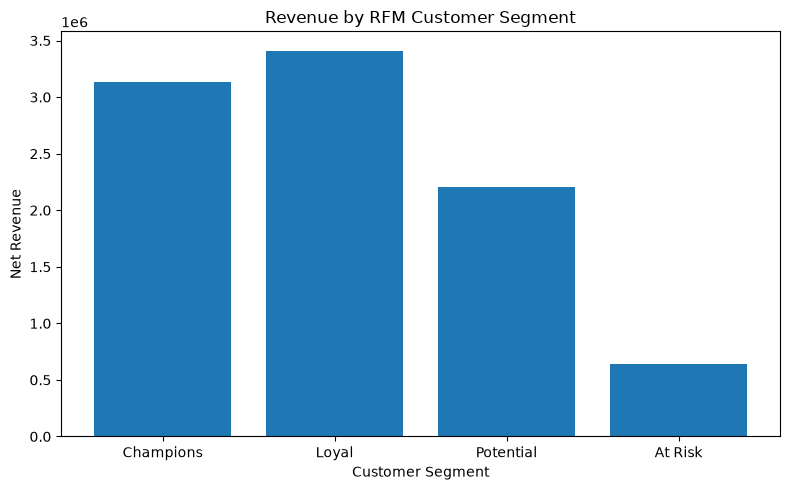

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. CUSTOMER IDs
# ==========================================

customer_ids = tx["customer_id"].unique()
n_customers = len(customer_ids)

recency = np.zeros(n_customers)
frequency = np.zeros(n_customers)
monetary = np.zeros(n_customers)

# Reference date
reference_date = tx["order_date"].max()


# ==========================================
# 2. CALCULATE RFM VALUES
# ==========================================

for i, customer_id in enumerate(customer_ids):

    customer_data = tx[
        tx["customer_id"] == customer_id
    ]

    # Recency
    last_purchase = customer_data["order_date"].max()

    recency[i] = (
        reference_date - last_purchase
    ).days

    # Frequency
    frequency[i] = len(
        customer_data["order_id"].unique()
    )

    # Monetary
    monetary[i] = np.sum(
        customer_data["net_revenue"].to_numpy()
    )


# ==========================================
# 3. NUMPY SCORING FUNCTION
# ==========================================

def create_scores(values, reverse=False):

    values = np.asarray(
        values,
        dtype=float
    )

    q20, q40, q60, q80 = np.percentile(
        values,
        [20, 40, 60, 80]
    )

    scores = np.zeros(
        len(values),
        dtype=int
    )

    scores[values <= q20] = 1

    scores[
        (values > q20) &
        (values <= q40)
    ] = 2

    scores[
        (values > q40) &
        (values <= q60)
    ] = 3

    scores[
        (values > q60) &
        (values <= q80)
    ] = 4

    scores[values > q80] = 5

    # Lower recency = better
    if reverse:
        scores = 6 - scores

    return scores


# ==========================================
# 4. RFM SCORES
# ==========================================

R_score = create_scores(
    recency,
    reverse=True
)

F_score = create_scores(
    frequency
)

M_score = create_scores(
    monetary
)


# ==========================================
# 5. COMBINED SCORE
# ==========================================

rfm_score = (
    R_score +
    F_score +
    M_score
)


# ==========================================
# 6. CREATE SEGMENTS
# ==========================================

segments = np.empty(
    n_customers,
    dtype=object
)

segments[rfm_score >= 13] = "Champions"

segments[
    (rfm_score >= 10) &
    (rfm_score < 13)
] = "Loyal"

segments[
    (rfm_score >= 7) &
    (rfm_score < 10)
] = "Potential"

segments[
    rfm_score < 7
] = "At Risk"


# ==========================================
# 7. REVENUE BY SEGMENT
# ==========================================

segment_names = np.array([
    "Champions",
    "Loyal",
    "Potential",
    "At Risk"
])

segment_revenue = np.zeros(
    len(segment_names)
)

for i, segment in enumerate(segment_names):

    mask = (
        segments == segment
    )

    segment_revenue[i] = np.sum(
        monetary[mask]
    )


# ==========================================
# 8. PRINT RESULTS
# ==========================================

for i in range(len(segment_names)):

    print(
        segment_names[i],
        ": $",
        round(segment_revenue[i], 2)
    )


# ==========================================
# 9. CREATE CHART
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    segment_names,
    segment_revenue
)

plt.title(
    "Revenue by RFM Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Net Revenue"
)

plt.tight_layout()

plt.savefig(
    "rfm_numpy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
orders = pd.read_sql(
    "SELECT * FROM orders",
    conn,
    parse_dates=["order_date"]
)

order_items = pd.read_sql(
    "SELECT * FROM order_items",
    conn
)

order_items = order_items.drop_duplicates()

orders = orders[
    orders["status"].isin([
        "completed",
        "returned"
    ])
]

tx = order_items.merge(
    orders[
        ["order_id", "customer_id", "order_date"]
    ],
    on="order_id",
    how="inner"
)

tx["discount"] = tx["discount"].fillna(0)

tx["net_revenue"] = (
    tx["quantity"]
    * tx["unit_price"]
    * (1 - tx["discount"])
)

In [24]:
# ------------------------------------------
# MONTHLY REVENUE
# ------------------------------------------

tx["month"] = (
    tx["order_date"]
    .dt.to_period("M")
)

monthly = (
    tx.groupby("month")["net_revenue"]
    .sum()
)

monthly_values = monthly.to_numpy(
    dtype=float
)


# ------------------------------------------
# X = MONTH INDEX
# ------------------------------------------

n_months = len(monthly_values)

month_index = np.arange(
    n_months,
    dtype=float
)

X = np.column_stack([
    np.ones(n_months),
    month_index
])

y = monthly_values


# ------------------------------------------
# NORMAL EQUATION
# β = (XᵀX)⁻¹Xᵀy
# ------------------------------------------

beta = np.linalg.inv(
    X.T @ X
) @ (
    X.T @ y
)

intercept = beta[0]
slope = beta[1]

print("Intercept:", intercept)
print("Slope:", slope)


# ------------------------------------------
# PREDICTIONS
# ------------------------------------------

predicted = X @ beta


# ------------------------------------------
# MANUAL R²
# ------------------------------------------

SS_res = np.sum(
    (y - predicted) ** 2
)

SS_tot = np.sum(
    (y - np.mean(y)) ** 2
)

R2 = 1 - (
    SS_res / SS_tot
)

print("R²:", R2)

Intercept: 111819.31402327295
Slope: 8516.596852638364
R²: 0.7325769472285524


In [25]:
future_index = np.array([
    n_months,
    n_months + 1
])

X_future = np.column_stack([
    np.ones(2),
    future_index
])

forecast = X_future @ beta

print(
    "Next month forecast:",
    forecast[0]
)

print(
    "Month +2 forecast:",
    forecast[1]
)

Next month forecast: 418416.80071825406
Month +2 forecast: 426933.3975708924


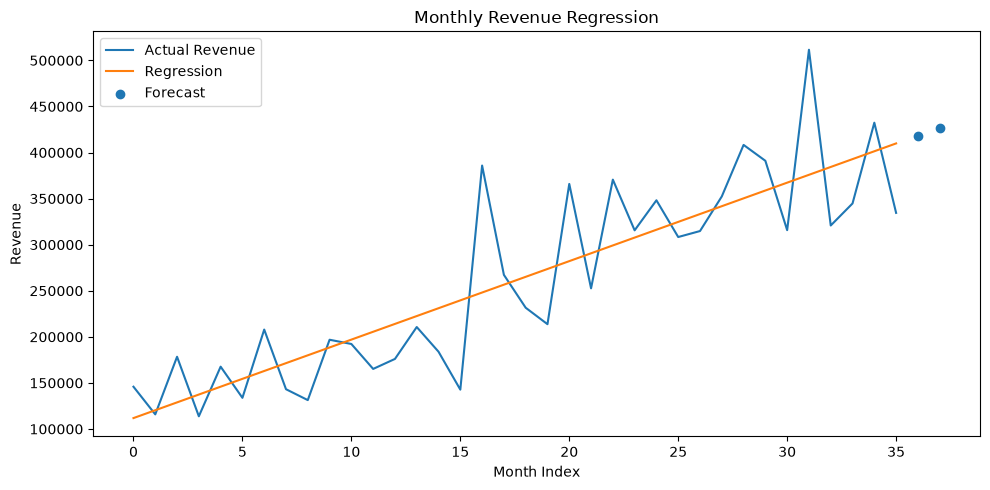

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    month_index,
    y,
    label="Actual Revenue"
)

plt.plot(
    month_index,
    predicted,
    label="Regression"
)

plt.scatter(
    future_index,
    forecast,
    label="Forecast"
)

plt.title(
    "Monthly Revenue Regression"
)

plt.xlabel("Month Index")
plt.ylabel("Revenue")

plt.legend()

plt.tight_layout()

plt.savefig(
    "numpy_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
print("Available DataFrames:")
print([name for name in globals() if isinstance(globals()[name], pd.DataFrame)])

Available DataFrames:
['orders', 'order_items', 'tx', 'customer_data']


In [20]:
print("R score range:", R_score.min(), R_score.max())
print("F score range:", F_score.min(), F_score.max())
print("M score range:", M_score.min(), M_score.max())

R score range: 1 5
F score range: 1 5
M score range: 1 5


In [21]:
print("R² =", R2)

assert R2 <= 1
assert R2 >= 0

R² = 0.7325769472285524


In [22]:
print(
    "Trials:",
    TRIALS
)

assert TRIALS >= 5000

Trials: 10000
